In [7]:
import pandas as pd
DATA_PATH = "/kaggle/input/datasets/uciml/iris/Iris.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape); print(df.head())

(150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


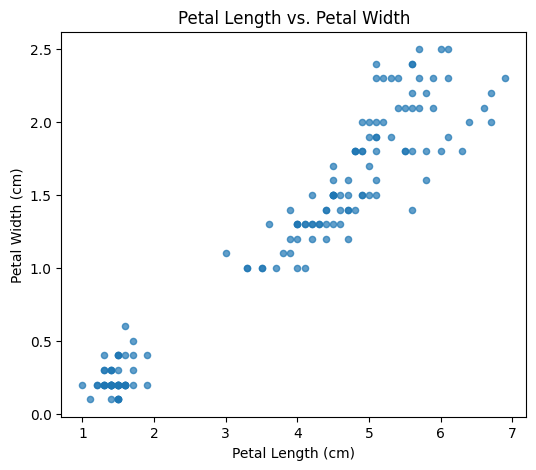

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.scatter(
    df["PetalLengthCm"],
    df["PetalWidthCm"],
    s=20,
    alpha=0.7
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs. Petal Width")

plt.show()

In [9]:
feature_cols = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

X = df[feature_cols].values

print(X[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [10]:
from sklearn.cluster import KMeans

# Create the K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit the model
kmeans.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [11]:
# Assign each data point to a cluster
df["Cluster"] = kmeans.predict(X)

# Display the number of samples in each cluster
print(df["Cluster"].value_counts())

Cluster
0    62
1    50
2    38
Name: count, dtype: int64


In [12]:
comparison = pd.crosstab(
    df["Cluster"],
    df["Species"]
)

print(comparison)

Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               48              14
1                 50                0               0
2                  0                2              36
